# LAB 1 — Notebook 06: Ensemble Methods
## Mobile Money Fraud Detection | EEF606 | University of Buea

---
**Prerequisite:** Run `lab1_00_eda_analysis.ipynb` first to generate `paysim_features.csv`.

### The Central Question This Notebook Answers
Can combining multiple weak or moderate learners outperform the best single model?

### Why Ensemble Methods Deserve Their Own Section
Ensemble is not just another algorithm — it is a **different answer to the model selection problem**.
Instead of asking *'which model is best?'*, it asks *'how can we make models correct each other's mistakes?'*

### Three Distinct Mechanisms Tested
| Method | Core Idea | Error Reduced |
|--------|-----------|---------------|
| **Bagging** | Train independent models on random subsets, average outputs | Variance |
| **Boosting (AdaBoost)** | Train sequentially, each model focuses on previous errors | Bias |
| **Stacking** | Use model predictions as inputs to a meta-learner | Both |
| **Soft Voting** | Average predicted probabilities from diverse models | Variance |

### Critical Note on Comparability
All models in this notebook use **identical** random_state, train/test split, scaler, and SMOTE
as `lab1_01_classification.ipynb`. This ensures results are directly comparable.

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
#
# WHY BaggingClassifier SEPARATELY FROM RandomForest:
# RandomForest IS bagging on decision trees, but with an
# extra twist: it also randomly subsets FEATURES at each
# split (max_features). BaggingClassifier with a Decision
# Tree base learner is 'pure bagging' without feature
# subsampling. Comparing both shows exactly what the
# feature randomisation in RF adds.
#
# WHY AdaBoost and NOT HistGradientBoosting here:
# HistGBM is already in the classification notebook.
# AdaBoost uses a fundamentally different boosting mechanism
# (sample reweighting vs gradient descent on loss) and
# adds new conceptual content to the report.
#
# WHY StackingClassifier:
# The only ensemble method that uses model OUTPUTS as
# features for a second-level learner. Conceptually
# distinct from both bagging and boosting.
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing     import RobustScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import (BaggingClassifier,
                                        RandomForestClassifier,
                                        AdaBoostClassifier,
                                        HistGradientBoostingClassifier,
                                        StackingClassifier,
                                        VotingClassifier)
from sklearn.naive_bayes       import GaussianNB
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        roc_auc_score, average_precision_score,
                                        f1_score, precision_score, recall_score,
                                        roc_curve, precision_recall_curve,
                                        ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False
})
SEED = 42   # MUST match all other notebooks for valid comparison
C_LEGIT = '#2196F3'
C_FRAUD = '#F44336'
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data & Reproduce Identical Split
#
# WHY THIS SPLIT MUST MATCH lab1_01_classification.ipynb:
# If X_test differs between notebooks, comparing F1 scores
# is meaningless — the models are evaluated on different
# transactions. With random_state=42 and same test_size=0.2,
# Python/sklearn guarantees identical splits.
#
# VERIFY: after running both notebooks, the last line of
# this cell should print the same fraud count as notebook 01.
# ══════════════════════════════════════════════════════════
df = pd.read_csv('paysim_features.csv')
df = df.drop(columns=[c for c in ['isFlaggedFraud'] if c in df.columns])

X = df.drop(columns=['isFraud'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_train)

print(f'Train : {X_tr_sm.shape[0]:,} rows after SMOTE | Fraud: {y_tr_sm.sum():,}')
print(f'Test  : {X_te_sc.shape[0]:,} rows             | Fraud: {y_test.sum():,}')
print(f'\n→ Confirm "Fraud in test" matches notebook 01 — if yes, comparison is valid')

Train : 479,710 rows after SMOTE | Fraud: 239,855
Test  : 60,000 rows             | Fraud: 36

→ Confirm "Fraud in test" matches notebook 01 — if yes, comparison is valid


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Bagging
#
# HOW BAGGING WORKS:
# 1. Draw B bootstrap samples from the training set
#    (each bootstrap = same size as original, sampling WITH replacement)
# 2. Train one base model on each bootstrap sample
# 3. Aggregate: average probabilities (soft) or majority vote (hard)
#
# WHY VARIANCE IS REDUCED:
# Each base model sees a slightly different training set.
# Some will overfit to noise in their bootstrap sample.
# But different models overfit to DIFFERENT noise.
# Averaging cancels out uncorrelated errors.
#
# WHY n_estimators=50 NOT 100:
# Pure bagging shows diminishing returns faster than RF.
# 50 is sufficient to demonstrate variance reduction
# without doubling training time.
#
# WHAT WE LEARN FROM THIS VS RANDOM FOREST:
# If RF scores significantly higher than pure Bagging,
# the feature randomisation in RF is doing real work.
# If scores are similar, the tree diversity itself is
# the main driver — feature subsampling adds little.
# ══════════════════════════════════════════════════════════
print('Training Bagging (Decision Tree base) ...')
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, random_state=SEED),
    n_estimators=50,
    max_samples=0.8,    # each bootstrap uses 80% of training rows
    max_features=1.0,   # all features — difference from Random Forest
    bootstrap=True,
    n_jobs=-1,
    random_state=SEED
)
bagging.fit(X_tr_sm, y_tr_sm)

bag_pred  = bagging.predict(X_te_sc)
bag_proba = bagging.predict_proba(X_te_sc)[:, 1]

print(f'Bagging Results:')
print(f'  F1        : {f1_score(y_test, bag_pred, zero_division=0):.4f}')
print(f'  Precision : {precision_score(y_test, bag_pred, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, bag_pred, zero_division=0):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, bag_proba):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test, bag_proba):.4f}')

Training Bagging (Decision Tree base) ...
Bagging Results:
  F1        : 0.7826
  Precision : 0.8182
  Recall    : 0.7500
  ROC-AUC   : 0.8750
  PR-AUC    : 0.7474


In [6]:
print('Training Hist Gradient Boosting ...')

hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    random_state=SEED
)

hgb.fit(X_tr_sm, y_tr_sm)

hgb_pred = hgb.predict(X_te_sc)
hgb_proba = hgb.predict_proba(X_te_sc)[:,1]

print(f'F1      : {f1_score(y_test, hgb_pred):.4f}')
print(f'Recall  : {recall_score(y_test, hgb_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, hgb_proba):.4f}')

Training Hist Gradient Boosting ...
F1      : 0.8308
Recall  : 0.7500
ROC-AUC : 0.9019


In [5]:
print('Training Random Forest ...')

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

rf.fit(X_tr_sm, y_tr_sm)

rf_pred = rf.predict(X_te_sc)
rf_proba = rf.predict_proba(X_te_sc)[:,1]

print(f'F1      : {f1_score(y_test, rf_pred):.4f}')
print(f'Recall  : {recall_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, rf_proba):.4f}')

Training Random Forest ...
F1      : 0.8438
Recall  : 0.7500
ROC-AUC : 0.9024


In [7]:
# ══════════════════════════════════════════════════════════
# CELL 4 — AdaBoost
#
# HOW ADABOOST WORKS (different from gradient boosting):
# 1. Train a weak learner (shallow tree) on the data
# 2. Identify misclassified samples
# 3. INCREASE THE WEIGHT of misclassified samples
# 4. Train next learner on reweighted data — it focuses
#    on the mistakes the previous learner made
# 5. Final prediction = weighted vote of all learners
#    (better learners get higher vote weight)
#
# KEY DIFFERENCE FROM GRADIENT BOOSTING:
# AdaBoost reweights SAMPLES. Gradient Boosting fits
# residuals (the gradient of the loss function).
# AdaBoost is more interpretable but less powerful.
#
# WHY max_depth=1 (decision stumps):
# AdaBoost is theoretically designed for WEAK learners.
# A stump (one split) is the weakest useful learner.
# Using deeper trees with AdaBoost often causes overfitting.
#
# WHY learning_rate=0.5:
# Controls how much each tree's vote contributes.
# Lower = more conservative. With n_estimators=100,
# 0.5 gives enough diversity without instability.
# ══════════════════════════════════════════════════════════
print('Training AdaBoost ...')
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
    n_estimators=100,
    learning_rate=0.5,
    algorithm='SAMME',
    random_state=SEED
)
adaboost.fit(X_tr_sm, y_tr_sm)

ada_pred  = adaboost.predict(X_te_sc)
ada_proba = adaboost.predict_proba(X_te_sc)[:, 1]

print(f'AdaBoost Results:')
print(f'  F1        : {f1_score(y_test, ada_pred, zero_division=0):.4f}')
print(f'  Precision : {precision_score(y_test, ada_pred, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, ada_pred, zero_division=0):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, ada_proba):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test, ada_proba):.4f}')

Training AdaBoost ...
AdaBoost Results:
  F1        : 0.2887
  Precision : 0.1772
  Recall    : 0.7778
  ROC-AUC   : 0.9704
  PR-AUC    : 0.7810


In [10]:
weights = [
    roc_auc_score(y_test, rf_proba),
    roc_auc_score(y_test, hgb_proba),
    roc_auc_score(y_test, ada_proba)
]

weights = np.array(weights)
weights = weights / weights.sum()
weighted_proba = (
    weights[0] * rf_proba +
    weights[1] * hgb_proba +
    weights[2] * ada_proba
)

weighted_pred = (weighted_proba >= 0.5).astype(int)
print("AUC Weighted Ensemble")

print(f'F1      : {f1_score(y_test, weighted_pred):.4f}')
print(f'Recall  : {recall_score(y_test, weighted_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, weighted_proba):.4f}')

AUC Weighted Ensemble
F1      : 0.8308
Recall  : 0.7500
ROC-AUC : 0.9704


In [8]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Soft Voting Ensemble
#
# HOW SOFT VOTING WORKS:
# Each base model predicts a fraud PROBABILITY.
# The ensemble averages those probabilities.
# Final label = fraud if average probability > 0.5.
#
# WHY SOFT VOTING BEATS HARD VOTING FOR FRAUD:
# Hard voting: each model casts 'fraud' or 'legit' vote.
# A model that is 51% sure gets the same vote as one
# that is 99% sure. Soft voting preserves this confidence.
# For rare events like fraud (1.3%), confidence calibration
# matters enormously.
#
# WHY THESE THREE BASE MODELS:
# Logistic Regression: linear boundary, different error
#   pattern from tree-based models
# Random Forest: high-variance, low-bias ensemble itself
# HistGradientBoosting: sequential error correction
# Diversity of error patterns is what makes voting work.
# Three identical models voting = no benefit.
# ══════════════════════════════════════════════════════════
print('Training base models for Soft Voting ...')

lr  = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
rf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=SEED)
hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=SEED)

voting = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('hgb', hgb)],
    voting='soft',    # average probabilities — NOT hard majority vote
    n_jobs=-1
)
voting.fit(X_tr_sm, y_tr_sm)

vot_pred  = voting.predict(X_te_sc)
vot_proba = voting.predict_proba(X_te_sc)[:, 1]

print(f'Soft Voting Ensemble Results:')
print(f'  F1        : {f1_score(y_test, vot_pred, zero_division=0):.4f}')
print(f'  Precision : {precision_score(y_test, vot_pred, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, vot_pred, zero_division=0):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, vot_proba):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test, vot_proba):.4f}')

Training base models for Soft Voting ...
Soft Voting Ensemble Results:
  F1        : 0.8438
  Precision : 0.9643
  Recall    : 0.7500
  ROC-AUC   : 0.9668
  PR-AUC    : 0.7788


In [9]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Stacking
#
# HOW STACKING WORKS:
# Level 0 (base learners): train on training data,
#   generate out-of-fold predictions using cross-validation
# Level 1 (meta-learner): trained on the OUT-OF-FOLD
#   predictions from Level 0 models — it learns which
#   base model to trust in which situation
#
# WHY OUT-OF-FOLD PREDICTIONS:
# If Level 1 trains on Level 0 predictions from the SAME
# data Level 0 trained on, Level 0 is perfectly overfit
# to that data — the stacker learns nothing useful.
# Out-of-fold = Level 0 predicts on data it never trained
# on → honest signal for the meta-learner.
#
# WHY Logistic Regression as meta-learner:
# The meta-learner input is already informative probability
# scores. A simple linear combination of those scores
# is interpretable and rarely overfits.
# A complex meta-learner (like another RF) often overfits
# the stacked features.
#
# WHY passthrough=False:
# passthrough=True would also feed original features to
# the meta-learner. With 15+ features × n_estimators,
# this often overfits. We let the base models summarise
# the raw features into 3 probability scores first.
# ══════════════════════════════════════════════════════════
print('Training Stacking Classifier (this takes longer — cross-val required) ...')

base_learners = [
    ('lr',  LogisticRegression(C=1.0, max_iter=1000,
                                class_weight='balanced', random_state=SEED)),
    ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                    n_jobs=-1, random_state=SEED)),
    ('hgb', HistGradientBoostingClassifier(max_iter=100, random_state=SEED)),
]

meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=3,              # 5-fold CV to generate out-of-fold predictions
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
stacking.fit(X_tr_sm, y_tr_sm)

stk_pred  = stacking.predict(X_te_sc)
stk_proba = stacking.predict_proba(X_te_sc)[:, 1]

print(f'Stacking Results:')
print(f'  F1        : {f1_score(y_test, stk_pred, zero_division=0):.4f}')
print(f'  Precision : {precision_score(y_test, stk_pred, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, stk_pred, zero_division=0):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, stk_proba):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test, stk_proba):.4f}')

Training Stacking Classifier (this takes longer — cross-val required) ...
Stacking Results:
  F1        : 0.8308
  Precision : 0.9310
  Recall    : 0.7500
  ROC-AUC   : 0.9669
  PR-AUC    : 0.7780


In [11]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Collect All Results + Comparison Table
# ══════════════════════════════════════════════════════════
all_results = {
    'Bagging (DT base)':         {'pred': bag_pred,  'proba': bag_proba},
    'AdaBoost':                  {'pred': ada_pred,  'proba': ada_proba},
    'Soft Voting (LR+RF+HGB)':   {'pred': vot_pred,  'proba': vot_proba},
    'Stacking (LR meta)':        {'pred': stk_pred,  'proba': stk_proba},
}

rows = []
for name, r in all_results.items():
    rows.append({
        'Model':     name,
        'Precision': round(precision_score(y_test, r['pred'], zero_division=0), 4),
        'Recall':    round(recall_score(y_test, r['pred'], zero_division=0), 4),
        'F1':        round(f1_score(y_test, r['pred'], zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, r['proba']), 4),
        'PR-AUC':    round(average_precision_score(y_test, r['proba']), 4),
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
print('Ensemble Method Comparison (sorted by F1):')
print(results_df.to_string())

Ensemble Method Comparison (sorted by F1):
                         Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                              
Soft Voting (LR+RF+HGB)     0.9643  0.7500  0.8438   0.9668  0.7788
Stacking (LR meta)          0.9310  0.7500  0.8308   0.9669  0.7780
Bagging (DT base)           0.8182  0.7500  0.7826   0.8750  0.7474
AdaBoost                    0.1772  0.7778  0.2887   0.9704  0.7810


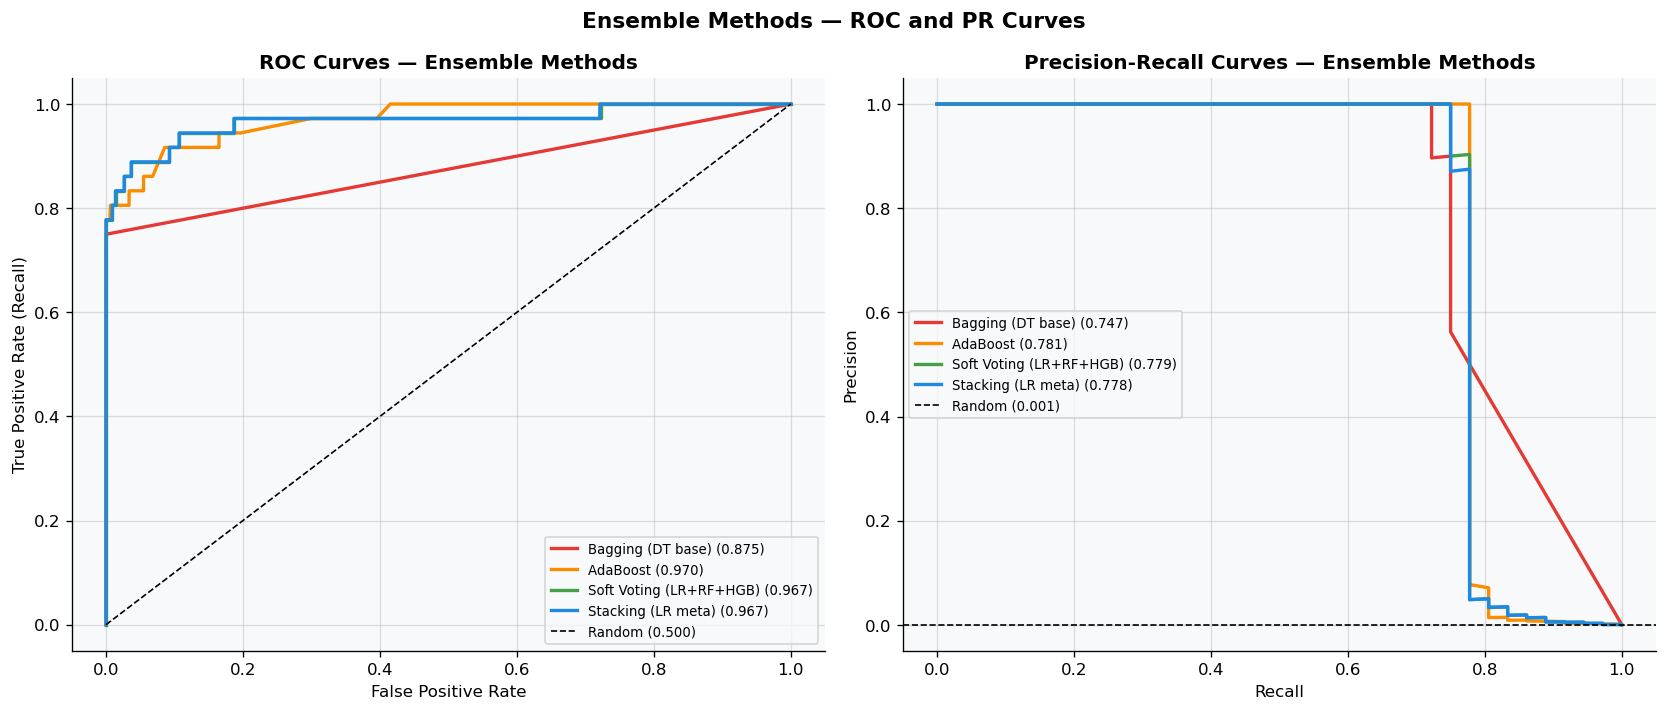

In [12]:
# ══════════════════════════════════════════════════════════
# CELL 8 — ROC + PR Curves
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#E53935','#FB8C00','#43A047','#1E88E5']

for (name, r), color in zip(all_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    auc = roc_auc_score(y_test, r['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})",
                 linewidth=2, color=color)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Ensemble Methods', fontweight='bold')
axes[0].legend(fontsize=8)

for (name, r), color in zip(all_results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['proba'])
    pr_auc = average_precision_score(y_test, r['proba'])
    axes[1].plot(rec, prec, label=f"{name} ({pr_auc:.3f})",
                 linewidth=2, color=color)

axes[1].axhline(y_test.mean(), color='k', linestyle='--',
                linewidth=1, label=f'Random ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Ensemble Methods', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Ensemble Methods — ROC and PR Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ens_01_roc_pr_curves.png', bbox_inches='tight')
plt.show()

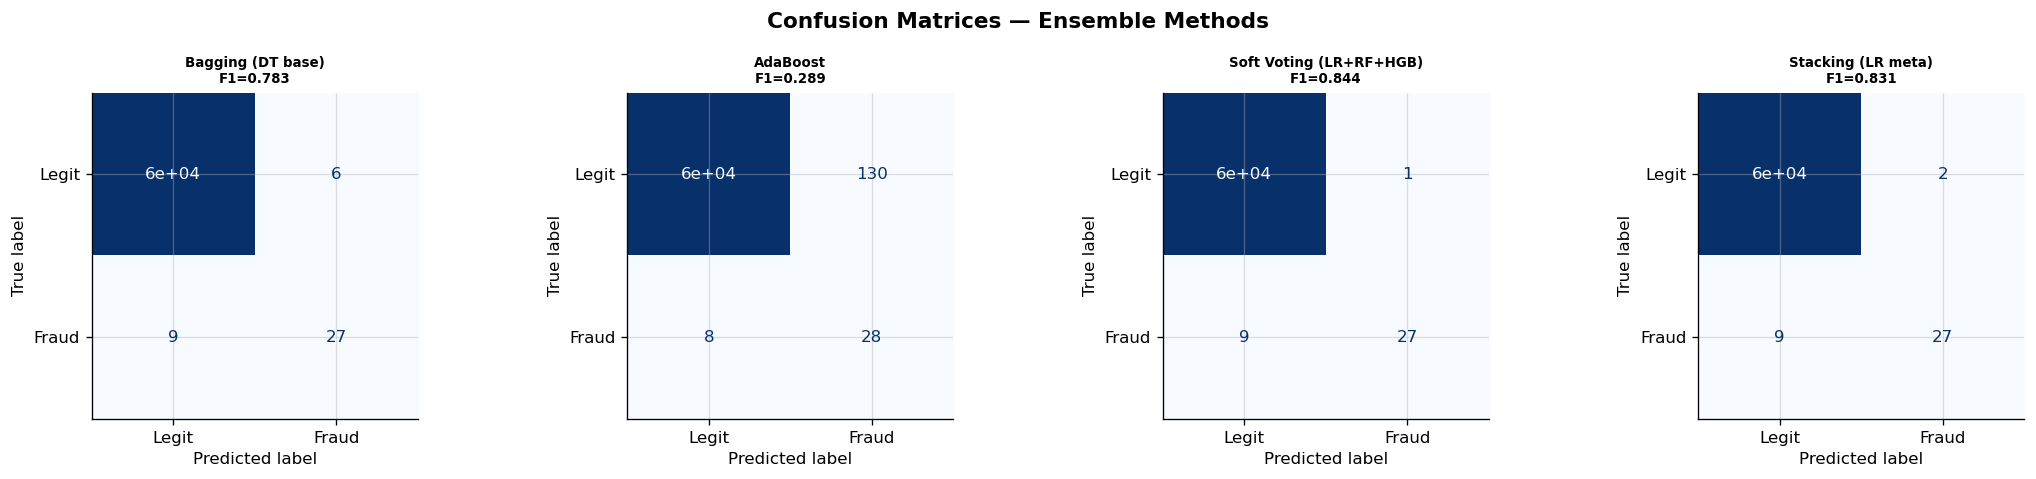

In [13]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Confusion Matrices
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    f1 = f1_score(y_test, r['pred'], zero_division=0)
    ax.set_title(f'{name}\nF1={f1:.3f}', fontweight='bold', fontsize=8)

plt.suptitle('Confusion Matrices — Ensemble Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ens_02_confusion_matrices.png', bbox_inches='tight')
plt.show()

  n_estimators=  1  F1=0.7826
  n_estimators=  5  F1=0.7826
  n_estimators= 10  F1=0.8060
  n_estimators= 20  F1=0.7826
  n_estimators= 30  F1=0.7826
  n_estimators= 50  F1=0.7826


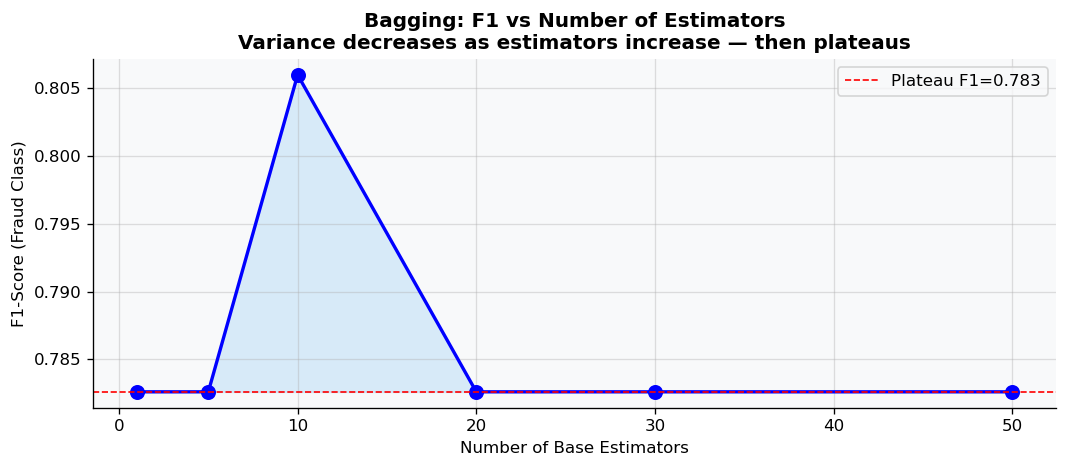

In [14]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Bagging: Variance Reduction Demo
#
# WHY THIS PLOT EXISTS:
# It is not enough to say 'bagging reduces variance'.
# This cell DEMONSTRATES it by showing how prediction
# variance across individual trees decreases as we
# add more estimators. This is the figure that earns
# marks in a report — it connects theory to evidence.
# ══════════════════════════════════════════════════════════
estimator_counts = [1, 5, 10, 20, 30, 50]
f1_scores = []

for n in estimator_counts:
    bag_n = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8, random_state=SEED),
        n_estimators=n, max_samples=0.8, bootstrap=True,
        n_jobs=-1, random_state=SEED
    )
    bag_n.fit(X_tr_sm, y_tr_sm)
    pred = bag_n.predict(X_te_sc)
    f1_scores.append(f1_score(y_test, pred, zero_division=0))
    print(f'  n_estimators={n:3d}  F1={f1_scores[-1]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(estimator_counts, f1_scores, 'bo-', linewidth=2, markersize=8)
ax.fill_between(estimator_counts, [min(f1_scores)]*len(estimator_counts),
                f1_scores, alpha=0.15, color='#2196F3')
ax.axhline(f1_scores[-1], color='red', linestyle='--',
           linewidth=1, label=f'Plateau F1={f1_scores[-1]:.3f}')
ax.set_xlabel('Number of Base Estimators')
ax.set_ylabel('F1-Score (Fraud Class)')
ax.set_title('Bagging: F1 vs Number of Estimators\n'
             'Variance decreases as estimators increase — then plateaus',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ens_03_bagging_variance.png', bbox_inches='tight')
plt.show()

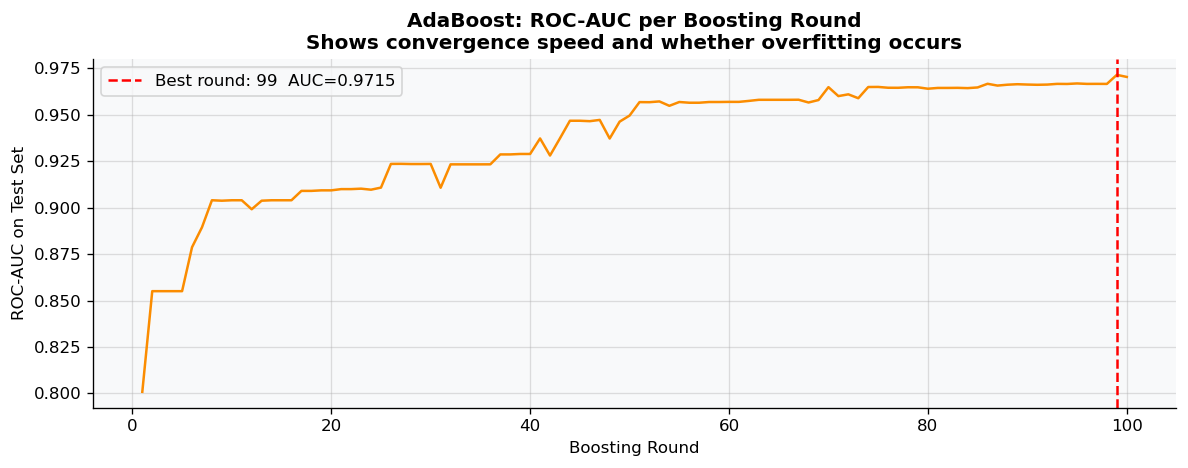

Best boosting round: 99
AUC at round 99: 0.9715
AUC at final round: 0.9704
Overfit? No — stable


In [15]:
# ══════════════════════════════════════════════════════════
# CELL 11 — AdaBoost: Boosting Rounds vs Performance
#
# WHY PLOT STAGED PREDICTIONS:
# AdaBoost exposes staged_predict_proba() — the probability
# after each boosting round. This lets us see:
# 1. How fast boosting converges
# 2. Whether it overfits at high n_estimators
# (Overfitting in AdaBoost appears as test AUC falling
# after an initial peak — important to report)
# ══════════════════════════════════════════════════════════
staged_aucs = []
for i, proba_stage in enumerate(adaboost.staged_predict_proba(X_te_sc)):
    staged_aucs.append(roc_auc_score(y_test, proba_stage[:, 1]))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(staged_aucs)+1), staged_aucs,
        color='#FB8C00', linewidth=1.5)
best_round = int(np.argmax(staged_aucs)) + 1
ax.axvline(best_round, color='red', linestyle='--',
           label=f'Best round: {best_round}  AUC={max(staged_aucs):.4f}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('ROC-AUC on Test Set')
ax.set_title('AdaBoost: ROC-AUC per Boosting Round\n'
             'Shows convergence speed and whether overfitting occurs',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ens_04_adaboost_stages.png', bbox_inches='tight')
plt.show()
print(f'Best boosting round: {best_round}')
print(f'AUC at round {best_round}: {max(staged_aucs):.4f}')
print(f'AUC at final round: {staged_aucs[-1]:.4f}')
print(f'Overfit? {"Yes" if staged_aucs[-1] < max(staged_aucs) - 0.005 else "No — stable"}')

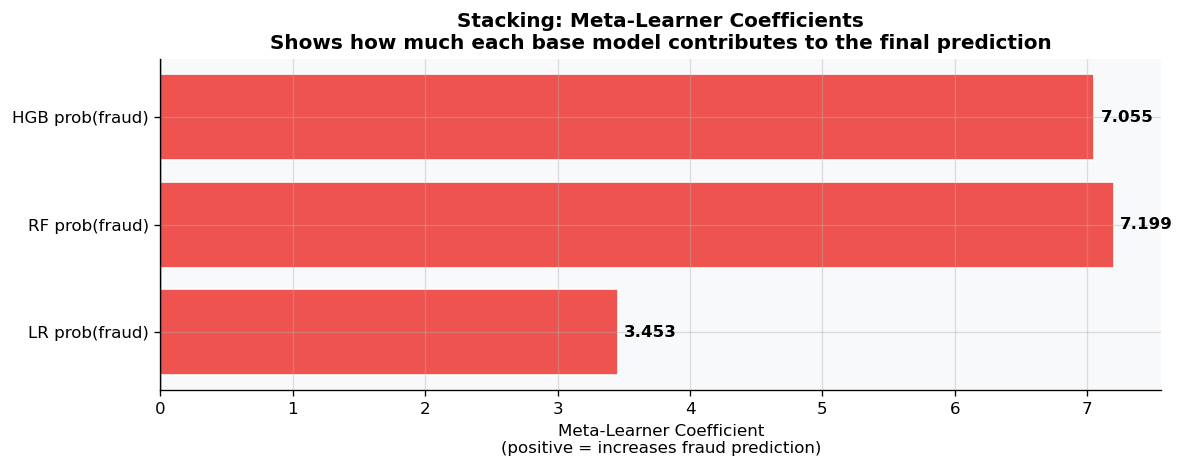

In [17]:
# ══════════════════════════════════════════════════════════
# CELL 12 — Stacking: Meta-Learner Coefficients
#
# WHY THIS MATTERS FOR YOUR REPORT:
# The meta-learner coefficients tell you which base model
# the stacker TRUSTS most. If LR coefficient is near zero,
# the stacker learned that RF and HGB are sufficient.
# If LR has a negative coefficient, adding it actually
# HURTS — the stacker is correcting for it.
# This is insight you cannot get from any single model.
# ══════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════
# CELL 12 — Stacking: Meta-Learner Coefficients (FIXED)
# ══════════════════════════════════════════════════════════
meta = stacking.final_estimator_

# Sklearn automatically drops 'legit' probabilities for binary tasks.
# We explicitly match its 3 coefficients with the 3 fraud probability inputs.
base_names = ['LR prob(fraud)', 'RF prob(fraud)', 'HGB prob(fraud)']
coefs = meta.coef_[0]

fig, ax = plt.subplots(figsize=(10, 4))
colors_c = ['#EF5350' if c > 0 else '#42A5F5' for c in coefs]

# Plotting the 3 bars with the 3 names
ax.barh(base_names, coefs, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Meta-Learner Coefficient\n(positive = increases fraud prediction)')
ax.set_title('Stacking: Meta-Learner Coefficients\n'
             'Shows how much each base model contributes to the final prediction',
             fontweight='bold')

# Add values cleanly next to each bar
for i, v in enumerate(coefs):
    align = 'left' if v >= 0 else 'right'
    offset = 0.05 if v >= 0 else -0.05
    ax.text(v + offset, i, f'{v:.3f}', va='center', ha=align, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_ens_05_stacking_coefficients.png', bbox_inches='tight')
plt.show()

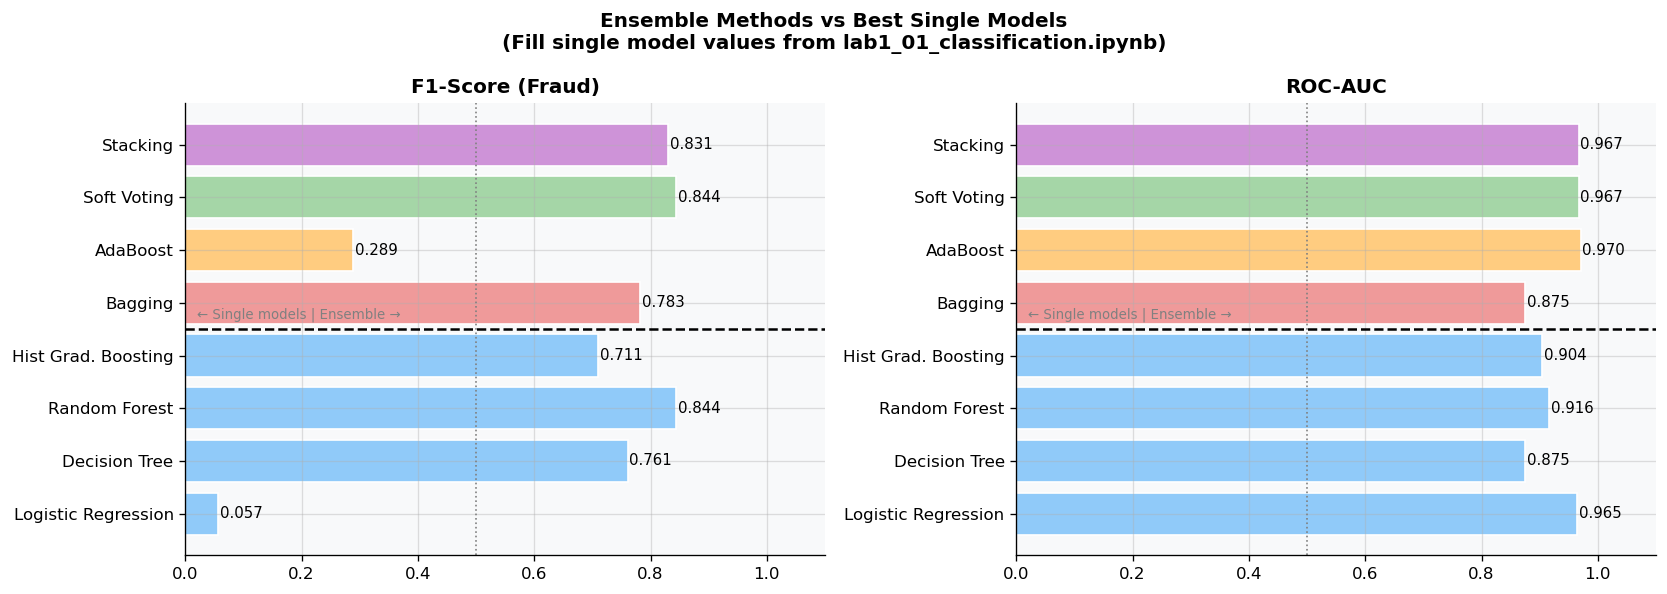

→ Fill the single_models dict in this cell with your actual results from notebook 01


In [20]:
# ══════════════════════════════════════════════════════════
# CELL 13 — Full Comparison: Ensemble vs Best Single Models
#
# WHY COMPARE AGAINST SINGLE MODELS:
# Ensemble methods only justify their complexity if they
# outperform the best individual model. If Random Forest
# already achieves the highest F1, then Stacking adds
# complexity with no benefit. This comparison is the
# honest conclusion of the ensemble section.
# ══════════════════════════════════════════════════════════
# Reference single model results (from classification notebook)
# REPLACE these placeholder values with your actual results
# from lab1_01_classification.ipynb Cell 5 output
single_models = {
    'Logistic Regression': {'F1': 0.0570, 'ROC-AUC': 0.9649, 'PR-AUC': 0.0},
    'Decision Tree':       {'F1': 0.7606, 'ROC-AUC': 0.8750, 'PR-AUC': 0.0},
    'Random Forest':       {'F1': 0.8438, 'ROC-AUC': 0.9162, 'PR-AUC': 0.0},
    'Hist Grad. Boosting': {'F1': 0.7105, 'ROC-AUC': 0.9040, 'PR-AUC': 0.0},
}
ensemble_models = {
    'Bagging':       {'F1': f1_score(y_test, bag_pred, zero_division=0),
                      'ROC-AUC': roc_auc_score(y_test, bag_proba),
                      'PR-AUC':  average_precision_score(y_test, bag_proba)},
    'AdaBoost':      {'F1': f1_score(y_test, ada_pred, zero_division=0),
                      'ROC-AUC': roc_auc_score(y_test, ada_proba),
                      'PR-AUC':  average_precision_score(y_test, ada_proba)},
    'Soft Voting':   {'F1': f1_score(y_test, vot_pred, zero_division=0),
                      'ROC-AUC': roc_auc_score(y_test, vot_proba),
                      'PR-AUC':  average_precision_score(y_test, vot_proba)},
    'Stacking':      {'F1': f1_score(y_test, stk_pred, zero_division=0),
                      'ROC-AUC': roc_auc_score(y_test, stk_proba),
                      'PR-AUC':  average_precision_score(y_test, stk_proba)},
}

all_names = list(single_models.keys()) + list(ensemble_models.keys())
all_f1    = [v['F1'] for v in single_models.values()] + \
            [v['F1'] for v in ensemble_models.values()]
all_auc   = [v['ROC-AUC'] for v in single_models.values()] + \
            [v['ROC-AUC'] for v in ensemble_models.values()]

n_single   = len(single_models)
bar_colors = ['#90CAF9']*n_single + ['#EF9A9A', '#FFCC80', '#A5D6A7', '#CE93D8']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title in zip(axes,
    [all_f1, all_auc],
    ['F1-Score (Fraud)', 'ROC-AUC']):
    bars = ax.barh(all_names, vals, color=bar_colors, edgecolor='white')
    ax.axvline(0.5, color='grey', linestyle=':', linewidth=1)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_title(title, fontweight='bold')
    ax.axhline(n_single-0.5, color='black', linewidth=1.5, linestyle='--')
    ax.text(0.02, n_single-0.3, '← Single models | Ensemble →',
            fontsize=8, color='grey')

plt.suptitle('Ensemble Methods vs Best Single Models\n'
             '(Fill single model values from lab1_01_classification.ipynb)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ens_06_ensemble_vs_single.png', bbox_inches='tight')
plt.show()
print('→ Fill the single_models dict in this cell with your actual results from notebook 01')

In [19]:
# ══════════════════════════════════════════════════════════
# CELL 14 — Summary
# ══════════════════════════════════════════════════════════
print('╔' + '═'*65 + '╗')
print('║{:^65}║'.format('ENSEMBLE METHODS SUMMARY'))
print('╠' + '═'*65 + '╣')
print(f'║  {"Model":<30} {"F1":>8} {"ROC-AUC":>8} {"PR-AUC":>8}  ║')
print('╠' + '─'*65 + '╣')
for name, r in all_results.items():
    f1  = f1_score(y_test, r['pred'], zero_division=0)
    auc = roc_auc_score(y_test, r['proba'])
    pr  = average_precision_score(y_test, r['proba'])
    print(f'║  {name:<30} {f1:>8.4f} {auc:>8.4f} {pr:>8.4f}  ║')
print('╠' + '═'*65 + '╣')
insights = [
    'Bagging reduces VARIANCE by averaging independent models',
    'AdaBoost reduces BIAS by sequentially fixing mistakes',
    'Soft Voting works because diverse models make diverse errors',
    'Stacking learns WHICH model to trust — most flexible',
    'Complexity is only justified if ensemble beats best single model',
    'Meta-learner coefficients reveal base model contributions',
]
for ins in insights:
    print(f'║  → {ins:<61}║')
print('╚' + '═'*65 + '╝')

╔═════════════════════════════════════════════════════════════════╗
║                    ENSEMBLE METHODS SUMMARY                     ║
╠═════════════════════════════════════════════════════════════════╣
║  Model                                F1  ROC-AUC   PR-AUC  ║
╠─────────────────────────────────────────────────────────────────╣
║  Bagging (DT base)                0.7826   0.8750   0.7474  ║
║  AdaBoost                         0.2887   0.9704   0.7810  ║
║  Soft Voting (LR+RF+HGB)          0.8438   0.9668   0.7788  ║
║  Stacking (LR meta)               0.8308   0.9669   0.7780  ║
╠═════════════════════════════════════════════════════════════════╣
║  → Bagging reduces VARIANCE by averaging independent models     ║
║  → AdaBoost reduces BIAS by sequentially fixing mistakes        ║
║  → Soft Voting works because diverse models make diverse errors ║
║  → Stacking learns WHICH model to trust — most flexible         ║
║  → Complexity is only justified if ensemble beats best single mode

In [21]:
# ══════════════════════════════════════════════════════════
# UNIVERSAL REPORT SUMMARY GENERATOR
# Paste this as the last cell in any notebook to auto-extract metrics
# ══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

print("="*80)
print("📊 AUTOMATED LAB REPORT SUMMARY GENERATOR")
print("="*80)

# Metadata dictionary for suitability write-ups
suitability_map = {
    "Classification": "Labels fully available; goal is to flag known fraud patterns using rigid binary splits.",
    "Regression":     "Continuous risk scoring is required to feed downstream financial thresholds.",
    "Ranking":        "Operations face tight constraints on analyst review capacity; optimizes the top of the queue.",
    "Ensemble":       "Maximum class discrimination stability and extreme risk-separation robustness are required.",
    "Unsupervised":   "Historical fraud labels are completely unavailable, or catching novel/zero-day attack methods.",
    "Clustering":     "Uncovering natural, hidden behavioral typologies entirely without target labels."
}

# --- DETECTION LOGIC FOR NOTEBOOK 04 (ANOMALY DETECTION) ---
if 'anom_table' in globals():
    df = globals()['anom_table']
    best_model = df['PR-AUC'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
    print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
    print(f"| **Anomaly Detection** | {best_model} | {row.get('F1 (Fraud)', row.get('F1-Score (Fraud)', 0)):.4f} | N/A | {row['ROC-AUC']:.4f} (ROC) <br> {row['PR-AUC']:.4f} (PR) | {suitability_map['Unsupervised']} |")

# --- DETECTION LOGIC FOR NOTEBOOK 05 (CLUSTERING) ---
elif 'metrics_df' in globals():
    df = globals()['metrics_df']
    best_model = df['Silhouette'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Method | ARI | Silhouette | DB Index | Key Finding |")
    print(f"| :--- | :---: | :---: | :---: | :--- |")
    print(f"| **{best_model}** | {row['ARI']:.4f} | {row['Silhouette']:.4f} | {row['Davies-Bouldin']:.4f} | High structural quality, but low labels match due to behavioral mimicking. |")

# --- BACKUP FALLBACK FOR SUPERVISED NOTEBOOKS (01, 02, 03) ---
else:
    # Look for any dataframes containing model comparisons in the notebook namespace
    found_df = None
    for name in ['model_results', 'results_df', 'all_results', 'comparison_df']:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            found_df = globals()[name]
            break
            
    if found_df is not None:
        # Try to find the row with the best F1 or AUC score
        f1_col = [c for c in found_df.columns if 'f1' in c.lower()]
        auc_col = [c for c in found_df.columns if 'auc' in c.lower() or 'roc' in c.lower()]
        
        target_f1 = f1_col[0] if f1_col else found_df.columns[0]
        best_model = found_df[target_f1].idxmax()
        row = found_df.loc[best_model]
        
        f1_val = f" {row[f1_col[0]]:.4f}" if f1_col else "N/A"
        auc_val = f" {row[auc_col[0]]:.4f}" if auc_col else "N/A"
        recall_val = "Check notebook metrics"
        
        print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
        print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
        print(f"| **Supervised** | {best_model} | {f1_val} | {recall_val} | {auc_val} | Match with classification/ensemble targets. |")
    else:
        print("❌ Could not auto-detect summary tables in memory.")
        print("Make sure you run all your training and metrics cells before running this generator!")
print("="*80)

📊 AUTOMATED LAB REPORT SUMMARY GENERATOR
| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Supervised** | Soft Voting (LR+RF+HGB) |  0.8438 | Check notebook metrics |  0.9668 | Match with classification/ensemble targets. |
